In [10]:
# %pip -q install yfinance scikit-learn pandas matplotlib --upgrade

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import TimeSeriesSplit


In [11]:
TARGET = "EWZ"                                # change to "IVV" or "ECH" if needed
PEERS  = ["EEM","SPY","ACWI","IEMG","VWO"]   # related ETFs as flow/attention proxies
SENTI  = ["^VIX"]                             # sentiment index(es)
START, END = "2012-01-01", "2025-01-01"
FFILL_LIMIT = 3                               # how many days to forward-fill peer/VIX gaps
MINP_ROLL   = 5                               # min periods in rolling stats (reduces early row loss)
MIN_NONNAN_FRAC = 0.50                        # keep features with >= this fraction of non-NaNs
MIN_NONNAN_ABS  = 120                         # and at least this many valid rows
SYMS = [TARGET] + PEERS + SENTI

In [12]:

# =========================
# HELPERS
# =========================
def _standardize_cols(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    # flatten tuples
    if isinstance(df.columns, pd.MultiIndex) or any(isinstance(c, tuple) for c in df.columns):
        flat = []
        for c in df.columns:
            if isinstance(c, tuple):
                parts = [str(p) for p in c if p is not None and str(p) != ""]
                name = parts[-1] if parts else ""
            else:
                name = str(c)
            flat.append(name)
        df = df.copy(); df.columns = flat
    # normalize casing
    return df.rename(columns={str(c): str(c).strip().title() for c in df.columns})

def _try_download(sym, start, end):
    # Try a few methods; return first frame that has 'Close'
    df = yf.download(sym, start=start, end=end, progress=False, auto_adjust=False)
    df = _standardize_cols(df)
    if df is not None and "Close" in df.columns:
        return df, "download(auto_adjust=False)"
    df = yf.download(sym, start=start, end=end, progress=False, auto_adjust=True)
    df = _standardize_cols(df)
    if df is not None and "Close" in df.columns:
        return df, "download(auto_adjust=True)"
    t = yf.Ticker(sym)
    df = _standardize_cols(t.history(start=start, end=end, auto_adjust=False))
    if df is not None and "Close" in df.columns:
        return df, "history(auto_adjust=False)"
    df = _standardize_cols(t.history(start=start, end=end, auto_adjust=True))
    if df is not None and "Close" in df.columns:
        return df, "history(auto_adjust=True)"
    return None, "all attempts failed"

def dl_one(sym, start=START, end=END):
    df, how = _try_download(sym, start, end)
    if df is None or df.empty:
        print(f"[FAIL] {sym}: no data ({how})"); return None
    if "Adj Close" not in df.columns and "Close" in df.columns:
        df["Adj Close"] = df["Close"]
    need = [c for c in ["Open","High","Low","Close","Adj Close","Volume"] if c in df.columns]
    out = df[need].copy()
    print(f"[OK] {sym}: {out.shape[0]} rows via {how} | cols={list(out.columns)}")
    return out

def assemble_field(raw_dict, field):
    parts = []
    for sym, df in raw_dict.items():
        if df is not None and field in df.columns and not df[field].empty:
            parts.append(df[field].rename(sym))
    return pd.concat(parts, axis=1).sort_index() if parts else pd.DataFrame()

def rolling_z(df, win=20, minp=MINP_ROLL):
    mu = df.rolling(win, min_periods=minp).mean()
    sd = df.rolling(win, min_periods=minp).std()
    return (df - mu) / sd.replace(0, np.nan)

def pct_change(df, n=1):
    return df.pct_change(n)

In [4]:

# =========================
# 1) DOWNLOAD
# =========================
raw = {sym: dl_one(sym) for sym in SYMS}
raw = {k:v for k,v in raw.items() if v is not None}
if TARGET not in raw:
    raise RuntimeError(f"Target {TARGET} missing entirely. Try TARGET='IVV' or adjust date range/network.")

Open  = assemble_field(raw, "Open")
High  = assemble_field(raw, "High")
Low   = assemble_field(raw, "Low")
Close = assemble_field(raw, "Close")
AdjC  = assemble_field(raw, "Adj Close")
Vol   = assemble_field(raw, "Volume")

if TARGET not in Close.columns or TARGET not in AdjC.columns:
    raise RuntimeError(f"{TARGET} missing in Close/Adj Close tables.")


[OK] EWZ: 3270 rows via history(auto_adjust=False) | cols=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
[OK] EEM: 3270 rows via history(auto_adjust=False) | cols=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
[OK] SPY: 3270 rows via history(auto_adjust=False) | cols=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
[OK] ACWI: 3270 rows via history(auto_adjust=False) | cols=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
[OK] IEMG: 3065 rows via history(auto_adjust=False) | cols=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
[OK] VWO: 3270 rows via history(auto_adjust=False) | cols=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
[OK] ^VIX: 3270 rows via history(auto_adjust=False) | cols=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [5]:
# =========================
# 2) ANCHOR TO TARGET CALENDAR
# =========================
Close_T = Close[[TARGET]].dropna()
AdjC_T  = AdjC[[TARGET]].reindex(Close_T.index).dropna()

peer_list = [p for p in PEERS if p in Close.columns]
Close_P = Close[peer_list].reindex(Close_T.index).ffill(limit=FFILL_LIMIT)
Vol_P   = Vol[peer_list].reindex(Close_T.index).ffill(limit=FFILL_LIMIT)

VIX = Close[["^VIX"]].reindex(Close_T.index).ffill(limit=FFILL_LIMIT) if "^VIX" in Close.columns else pd.DataFrame(index=Close_T.index)

Close = pd.concat([Close_T, Close_P, VIX], axis=1)
AdjC  = AdjC_T
Vol   = Vol_P.fillna(0)

assert TARGET in Close.columns and TARGET in AdjC.columns, "TARGET lost after anchoring."
print("Anchored — Close:", Close.shape, "| AdjC:", AdjC.shape, "| Vol:", Vol.shape)


Anchored — Close: (3270, 7) | AdjC: (3270, 1) | Vol: (3270, 5)


In [6]:
# =========================
# 3) FEATURES (robust)
# =========================
DolVol = Close[peer_list] * Vol[peer_list]

X_parts = [
    rolling_z(DolVol, 20).add_prefix("z_dv20_"),
    rolling_z(Vol[peer_list], 20).add_prefix("z_vol20_"),
    pct_change(DolVol, 1).add_prefix("d1_dv_"),
    pct_change(DolVol, 5).add_prefix("d5_dv_"),
    pct_change(Vol[peer_list], 1).add_prefix("d1_vol_"),
    pct_change(Vol[peer_list], 5).add_prefix("d5_vol_"),
]

if "^VIX" in Close.columns:
    vix = Close["^VIX"].to_frame("VIX")
    X_parts += [
        rolling_z(vix, 20).rename(columns={"VIX":"z_vix20"}),
        pct_change(vix, 1).rename(columns={"VIX":"d1_vix"}),
        pct_change(vix, 5).rename(columns={"VIX":"d5_vix"}),
    ]

X = pd.concat(X_parts, axis=1)

# prune weak-coverage columns
min_non_nan = max(MIN_NONNAN_ABS, int(MIN_NONNAN_FRAC * len(X)))
good_cols = [c for c in X.columns if X[c].notna().sum() >= min_non_nan]
X = X[good_cols]

# light gap fill and final scrub
X = X.ffill(limit=FFILL_LIMIT).bfill(limit=FFILL_LIMIT)
X = X.replace([np.inf, -np.inf], np.nan).dropna(how="any")

print("After cleaning — X:", X.shape, "| kept features:", len(good_cols))


After cleaning — X: (3060, 30) | kept features: 30


In [7]:
# =========================
# 4) LABEL (next-day direction)
# =========================
ret1 = AdjC[TARGET].pct_change().shift(-1)
y = (ret1 > 0).astype("float").reindex(X.index)
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask].astype(int)

print("Aligned — X:", X.shape, "| y:", y.shape)
if len(X) < 100:
    print("[WARN] Few samples; consider shorter peer list, more fill (FFILL_LIMIT=5), or later START date.")


Aligned — X: (3060, 30) | y: (3060,)


In [8]:
# =========================
# 5) MODEL: holdout + TimeSeriesSplit CV
# =========================
split = int(len(X) * 0.8)
Xtr, Xte = X.iloc[:split], X.iloc[split:]
ytr, yte = y.iloc[:split], y.iloc[split:]

clf = LogisticRegression(max_iter=2000)
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)
print(f"\nHoldout accuracy (80/20): {accuracy_score(yte, pred):.3f}")
print(classification_report(yte, pred, digits=3))

tscv = TimeSeriesSplit(n_splits=5)
cv_acc = []
for tr, te in tscv.split(X):
    m = LogisticRegression(max_iter=2000)
    m.fit(X.iloc[tr], y.iloc[tr])
    cv_acc.append(accuracy_score(y.iloc[te], m.predict(X.iloc[te])))
print("TS CV accuracies:", [round(a,3) for a in cv_acc], "| Mean:", round(np.mean(cv_acc),3))



Holdout accuracy (80/20): 0.500
              precision    recall  f1-score   support

           0      0.504     0.432     0.465       308
           1      0.497     0.569     0.531       304

    accuracy                          0.500       612
   macro avg      0.500     0.500     0.498       612
weighted avg      0.500     0.500     0.498       612

TS CV accuracies: [0.5, 0.496, 0.508, 0.486, 0.52] | Mean: 0.502



Table — Accuracy vs Selected(n)
      n  median_CV_accuracy  gain_vs_all_%
0    1            0.503922       0.784314
1    2            0.513725       2.745098
2    3            0.509804       1.960784
3    4            0.505882       1.176471
4    5            0.523529       4.705882
5    6            0.527451       5.490196
6    7            0.519608       3.921569
7    8            0.521569       4.313725
8    9            0.521569       4.313725
9   10            0.513725       2.745098
10  11            0.509804       1.960784
11  12            0.513725       2.745098


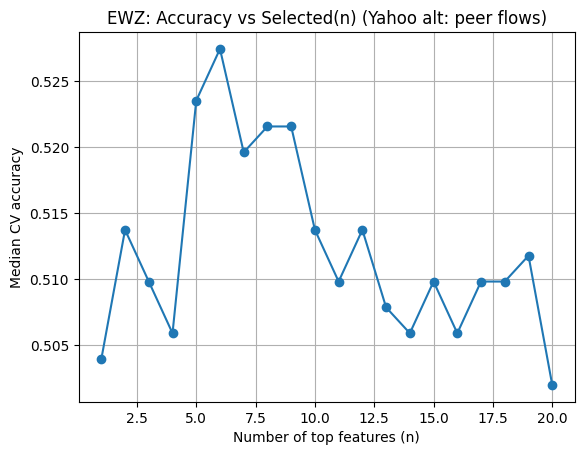

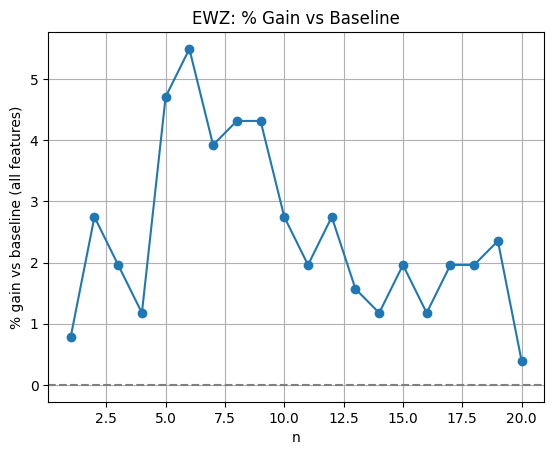

In [9]:
# =========================
# 6) Selected(n) table + plots
# =========================
corrs = X.corrwith(y).abs().sort_values(ascending=False)
ranking = list(corrs.index)

def median_cv_accuracy(cols, n_splits=5):
    accs = []
    for tr, te in TimeSeriesSplit(n_splits=n_splits).split(X):
        m = LogisticRegression(max_iter=2000)
        m.fit(X.iloc[tr][cols], y.iloc[tr])
        accs.append(accuracy_score(y.iloc[te], m.predict(X.iloc[te][cols])))
    return float(np.median(accs)) if accs else np.nan

baseline = median_cv_accuracy(ranking)

rows = []
max_n = min(20, len(ranking))
for n in range(1, max_n + 1):
    cols = ranking[:n]
    accn = median_cv_accuracy(cols)
    gain = np.nan
    if baseline and not np.isnan(baseline) and baseline != 0:
        gain = 100 * (accn - baseline) / baseline
    rows.append((n, accn, gain))

tbl = pd.DataFrame(rows, columns=["n", "median_CV_accuracy", "gain_vs_all_%"])
print("\nTable — Accuracy vs Selected(n)\n", tbl.head(12))

plt.figure()
plt.plot(tbl["n"], tbl["median_CV_accuracy"], marker="o")
plt.xlabel("Number of top features (n)"); plt.ylabel("Median CV accuracy")
plt.title(f"{TARGET}: Accuracy vs Selected(n) (Yahoo alt: peer flows)")
plt.grid(True); plt.show()

plt.figure()
plt.plot(tbl["n"], tbl["gain_vs_all_%"], marker="o")
plt.axhline(0, ls="--", c="gray")
plt.xlabel("n"); plt.ylabel("% gain vs baseline (all features)")
plt.title(f"{TARGET}: % Gain vs Baseline")
plt.grid(True); plt.show()